## [D] Explorative Data Analysis

In [1]:
import pandas as pd
import numpy as np
import os

# Visualization libraries
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

from scipy.stats import pearsonr

In [ ]:
path = "data/processed_data/"
pols_fe_re_gmm_data = "03_pols_fe_re_gmm_data.csv" # Summary stats on non winsorized data
bc_data = "03_bc_data.csv"

date_column = "date" 
stock_column = "stock"

os.chdir("..")
print(os.getcwd())

/workspaces/master-thesis-submission/src


In [3]:
pols_fe_re_gmm_data = pd.read_csv(path + pols_fe_re_gmm_data)
bc_data = pd.read_csv(path + bc_data)

pols_fe_re_gmm_data[date_column] = pd.to_datetime(pols_fe_re_gmm_data[date_column]).dt.date
bc_data[date_column] = pd.to_datetime(bc_data[date_column]).dt.date

## 2. Visuals

### Helper Functions

In [ ]:
def plotHeatmap(corr_matrix, title):
  """Plots a heatmap of the correlation matrix."""
  plt.figure(figsize=(12, 10))

  #Plot Heatmap
  sns.heatmap(corr_matrix, annot = True, cmap = 'coolwarm', vmin = -1, vmax = 1, center = 0, fmt='.2f')

  # Move x-axis to top
  plt.gca().xaxis.set_ticks_position('top')
  plt.gca().xaxis.set_label_position('top')

  #Rotate labels on X-Axis
  plt.xticks(rotation = 60)

  #Add title
  plt.title(title)
  plt.show()

In [5]:
def getMedianOrMeanSummaryTable(data, group_cols, value_col, median=False, decimals=2, sort_by=None, ascending=False):
    """Returns a summary table with mean or median and count for a value column, grouped by specified columns."""

    stat_col = "median" if median else "mean"
    stat_func = "median" if median else "mean"

    summary = (
        data.groupby(group_cols, as_index=False)[value_col]
            .agg(**{stat_col: stat_func, "count": "count"})
    )

    # Round numeric columns
    summary[stat_col] = summary[stat_col].round(decimals)

    if sort_by is None:
        sort_by = stat_col

    summary = summary.sort_values(by=sort_by, ascending=ascending).reset_index(drop=True)

    return summary

In [7]:
def one_step_summary_stats_table(df, vars_list, percentiles= (0.005, 0.05, 0.25, 0.50, 0.75, 0.95, 0.995)):
    """
    Build a summary-statistics table where each row is a variable and columns are:
    mean, std, skewness, kurt, min, p005, p05, p25, median, p75, p95, p995, max, n.
    """
    missing = [v for v in vars_list if v not in df.columns]
    if missing:
        raise KeyError(f"Variables not found in df: {missing}")

    rows = []
    for v in vars_list:
        s = pd.to_numeric(df[v], errors="coerce")  # coerce non-numeric to NaN

        qs = s.quantile(list(percentiles))
        # Map percentile names
        q_map = {
            "p005": round(qs.get(0.005, np.nan),4),
            "p05": round(qs.get(0.05, np.nan),4),
            "p25": round(qs.get(0.25, np.nan),4),
            "median": round(qs.get(0.50, np.nan),4),
            "p75": round(qs.get(0.75, np.nan),4),
            "p95": round(qs.get(0.95, np.nan),4),
            "p995": round(qs.get(0.995, np.nan),4),
        }

        rows.append(
            {
                "variable": v,
                "mean": round(s.mean(),4),
                "std": round(s.std(ddof=1),4),
                "skewness": round(s.skew(),4),
                "kurt": round(s.kurt(),4),
                "min": round(s.min(),4),
                **q_map,
                "max": round(s.max(),4),
                "n": int(s.count()),
            }
        )

    out = pd.DataFrame(rows).set_index("variable")

    # Order columns exactly as requested
    col_order = [
        "mean", "std", "skewness", "kurt",
        "min", "p005", "p05", "p25", "median", "p75", "p95", "p995",
        "max", "n"
    ]
    
    out = out[col_order]

    return out

In [8]:
def two_step_summary_stats_table(df, vars_list, date_col, percentiles = (0.005, 0.05, 0.25, 0.50, 0.75, 0.95, 0.995), rounding= 4) :
    
    rows = []

    for v in vars_list:
        temp = df[[date_col, v]].copy()
        temp[v] = pd.to_numeric(temp[v], errors="coerce")

        # Step 1: compute cross-sectional stats within each time period (e.g., quarter)
        time_period_stats = []

        for date, group in temp.groupby(date_col):
            s = group[v].dropna()

            if len(s) == 0:
                continue

            qs = s.quantile(list(percentiles))

            time_period_stats.append({
                "date": date,
                "mean": s.mean(),
                "std": s.std(ddof=1),
                "skewness": s.skew(),
                "kurt": s.kurt(),
                "min": s.min(),
                "p005": qs.get(0.005, np.nan),
                "p05": qs.get(0.05, np.nan),
                "p25": qs.get(0.25, np.nan),
                "median": qs.get(0.50, np.nan),
                "p75": qs.get(0.75, np.nan),
                "p95": qs.get(0.95, np.nan),
                "p995": qs.get(0.995, np.nan),
                "max": s.max(),
                "n": s.count(),
            })

        time_period_stats_df = pd.DataFrame(time_period_stats)

        if time_period_stats_df.empty:
            rows.append({
                "variable": v,
                "mean": np.nan,
                "std": np.nan,
                "skewness": np.nan,
                "kurt": np.nan,
                "min": np.nan,
                "p005": np.nan,
                "p05": np.nan,
                "p25": np.nan,
                "median": np.nan,
                "p75": np.nan,
                "p95": np.nan,
                "p995": np.nan,
                "max": np.nan,
                "n": np.nan,
            })
            continue

        # Step 2: take time-series average of quarterly statistics
        rows.append({
            "variable": v,
            "mean": round(time_period_stats_df["mean"].mean(), rounding),
            "std": round(time_period_stats_df["std"].mean(), rounding),
            "skewness": round(time_period_stats_df["skewness"].mean(), rounding),
            "kurt": round(time_period_stats_df["kurt"].mean(), rounding),
            "min": round(time_period_stats_df["min"].mean(), rounding),
            "p005": round(time_period_stats_df["p005"].mean(), rounding),
            "p05": round(time_period_stats_df["p05"].mean(), rounding),
            "p25": round(time_period_stats_df["p25"].mean(), rounding),
            "median": round(time_period_stats_df["median"].mean(), rounding),
            "p75": round(time_period_stats_df["p75"].mean(), rounding),
            "p95": round(time_period_stats_df["p95"].mean(), rounding),
            "p995": round(time_period_stats_df["p995"].mean(), rounding),
            "max": round(time_period_stats_df["max"].mean(), rounding),
            "n": round(time_period_stats_df["n"].mean(), rounding),
        })

    out = pd.DataFrame(rows).set_index("variable")

    col_order = [
        "mean", "std", "skewness", "kurt",
        "min", "p005", "p05", "p25", "median", "p75", "p95", "p995",
        "max", "n"
    ]
    out = out[col_order]

    return out

### Summary Statistics

In [9]:
vars_to_summarize_1 = ["stock_return_quarterly", 
                    "beta", 
                    "size", 
                    "value", 
                    "profitability", 
                    "investment",
                    "price_momentum",
                    "esg_score",
                    "esg_momentum"]

# Time Series means of cross-sectional summary stats for each variable (e.g., mean of quarterly means, mean of quarterly stds, etc.)
stats_df_1 = two_step_summary_stats_table(pols_fe_re_gmm_data, date_col=date_column, vars_list=vars_to_summarize_1)
stats_df_1.head(50)

,mean,std,skewness,kurt,min,p005,p05,p25,median,p75,p95,p995,max,n
variable,,,,,,,,,,,,,,
stock_return_quarterly,0.0181,0.1310,0.5277,4.0423,-0.4620,-0.3154,-0.1756,-0.0638,0.0129,0.0916,0.2283,0.4458,0.7207,531.1579
beta,1.0820,0.7732,0.3358,1.2666,-1.5666,-0.8477,-0.0731,0.5769,1.0410,1.5508,2.3669,3.4630,4.3414,531.1579
size,23.0352,1.0373,0.7471,0.1477,21.1523,21.3272,21.6458,22.2655,22.8499,23.6762,25.0558,26.0845,26.3947,531.1579
value,0.5723,0.6090,4.5645,42.2715,-0.6976,-0.1424,0.0794,0.2183,0.4106,0.7475,1.5185,3.4577,7.3888,531.1579
profitability,0.2213,0.8436,2.9082,181.6107,-8.2635,-1.0750,-0.0503,0.1102,0.1868,0.2823,0.5680,1.9979,12.6070,531.1579
investment,0.0265,0.1859,9.0222,147.4305,-0.3644,-0.1607,-0.0434,-0.0022,0.0033,0.0242,0.1175,0.7030,3.2664,531.1579
price_momentum,0.0372,0.1893,0.8696,3.9597,-0.5395,-0.4120,-0.2320,-0.0832,0.0244,0.1366,0.3488,0.7161,1.0789,531.1579
esg_score,67.2263,15.4759,-0.7881,0.4905,8.7821,19.9738,37.7607,58.0424,69.6416,78.8027,88.2009,92.8206,94.2944,531.1579
esg_momentum,1.5798,5.5709,0.9780,6.0434,-20.4671,-11.7429,-5.8068,-1.6236,0.9353,4.1300,11.1692,22.0315,34.6089,531.1579


In [10]:
vars_to_summarize_2 = ["stock_return", "mcap"]

# Time Series means of cross-sectional summary stats for each variable (e.g., mean of quarterly means, mean of quarterly stds, etc.)
stats_df_2 = two_step_summary_stats_table(bc_data, date_col=date_column, vars_list=vars_to_summarize_2)
stats_df_2.head(50)

,mean,std,skewness,kurt,min,p005,p05,p25,median,p75,p95,p995,max,n
variable,,,,,,,,,,,,,,
stock_return,4.900000e-03,7.460000e-02,0.1594,5.2080,-3.401000e-01,-2.066000e-01,-1.086000e-01,-3.860000e-02,3.900000e-03,4.720000e-02,1.212000e-01,2.342000e-01,3.806000e-01,585.1875
mcap,1.985257e+10,3.239487e+10,4.3363,24.8714,1.413727e+09,1.813477e+09,2.520031e+09,4.763061e+09,8.741480e+09,2.037690e+10,7.510107e+10,2.102260e+11,2.991184e+11,585.1875


In [11]:
vars_to_summarize_3 = [
                    "dividend_yield_ttm",
                    "term_spread",
                    "default_spread",
                    "spot_rate_3m_government_bond",
                    ]

#Time Series Statistics
stats_df_3 = one_step_summary_stats_table(bc_data, vars_list=vars_to_summarize_3)
stats_df_3.head(50)

,mean,std,skewness,kurt,min,p005,p05,p25,median,p75,p95,p995,max,n
variable,,,,,,,,,,,,,,
dividend_yield_ttm,0.0351,0.0045,0.0524,-0.3544,0.0259,0.0259,0.0271,0.0329,0.0350,0.0377,0.0432,0.0459,0.0459,65541
term_spread,0.0041,0.0079,-0.7171,-0.1220,-0.0170,-0.0170,-0.0110,0.0010,0.0054,0.0107,0.0136,0.0192,0.0192,65541
default_spread,0.0087,0.0020,0.9470,1.2378,0.0060,0.0060,0.0064,0.0070,0.0085,0.0103,0.0117,0.0170,0.0170,65541
spot_rate_3m_government_bond,0.0048,0.0169,0.9299,-0.8774,-0.0093,-0.0093,-0.0080,-0.0070,-0.0062,0.0194,0.0378,0.0382,0.0382,65541


### Variance Inflation Factor

In [22]:
#Source: https://github.com/bilkent-sna/negotiating-comfort-with-llm-agents/blob/main/analysis.ipynb

reg_vars_pols = [
    "beta", "size", "value", "profitability", "investment",
    "price_momentum", "esg_score", "esg_momentum"
]

reg_vars_bc = [
    "dividend_yield_ttm",
    "term_spread",
    "default_spread",
    "spot_rate_3m_government_bond",
]

X_vif_pols = pols_fe_re_gmm_data[reg_vars_pols].copy()
X_vif_bc = bc_data[reg_vars_bc].copy()

X_vif_pols = X_vif_pols.dropna()
X_vif_bc = X_vif_bc.dropna()

# add intercept
X_vif_pols = add_constant(X_vif_pols)
X_vif_bc = add_constant(X_vif_bc)

# calculate VIF for each column
vif_pols = pd.DataFrame({
    "Variable": X_vif_pols.columns,
    "VIF": [variance_inflation_factor(X_vif_pols.values, i) for i in range(X_vif_pols.shape[1])]
})

vif_bc = pd.DataFrame({
    "Variable": X_vif_bc.columns,
    "VIF": [variance_inflation_factor(X_vif_bc.values, i) for i in range(X_vif_bc.shape[1])]
})

In [23]:
print(vif_pols)

         Variable         VIF
0           const  565.201341
1            beta    1.033917
2            size    1.292459
3           value    1.071983
4   profitability    1.005383
5      investment    1.001778
6  price_momentum    1.045647
7       esg_score    1.252656
8    esg_momentum    1.016180


In [24]:
print(vif_bc)

                       Variable        VIF
0                         const  66.803635
1            dividend_yield_ttm   1.191325
2                   term_spread   2.531808
3                default_spread   1.182110
4  spot_rate_3m_government_bond   2.422988


### Heatmap

Here I get the correlation coefficients of the variables

In [16]:
column_names = ["beta", "size", "value", "profitability", "investment", "price_momentum", "esg_score", "esg_momentum"]
columns = pols_fe_re_gmm_data[column_names].columns

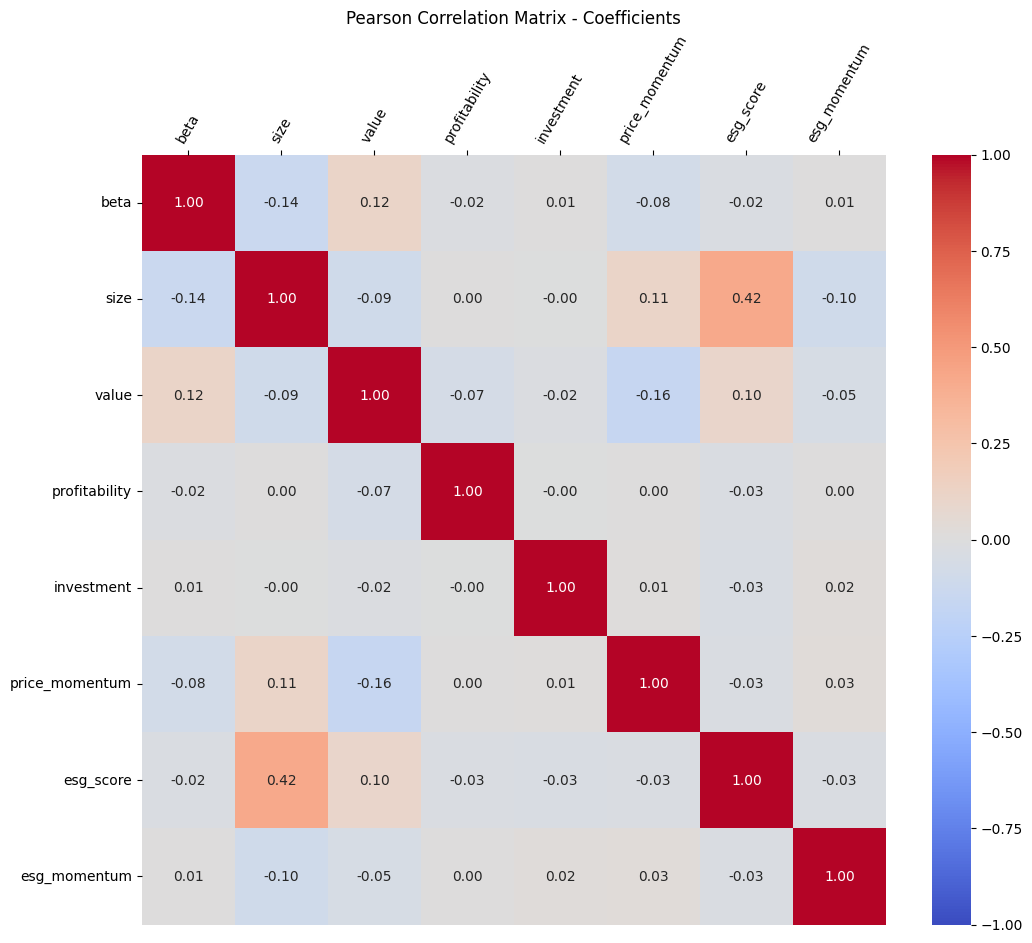

In [17]:
#Correlation & P-Value Matrices
corr_matrix_pearson = pd.DataFrame(index=columns, columns=columns, dtype=float)
pval_matrix_pearson = pd.DataFrame(index=columns, columns=columns, dtype=float)

for col1 in columns:
    for col2 in columns:

        #Calculates correlation coefficient and p-value
        corr, pval = pearsonr(pols_fe_re_gmm_data[col1], pols_fe_re_gmm_data[col2])

        #Adds values to dataframes
        corr_matrix_pearson.loc[col1, col2] = corr
        pval_matrix_pearson.loc[col1, col2] = pval

plotHeatmap(corr_matrix_pearson, "Pearson Correlation Matrix - Coefficients")

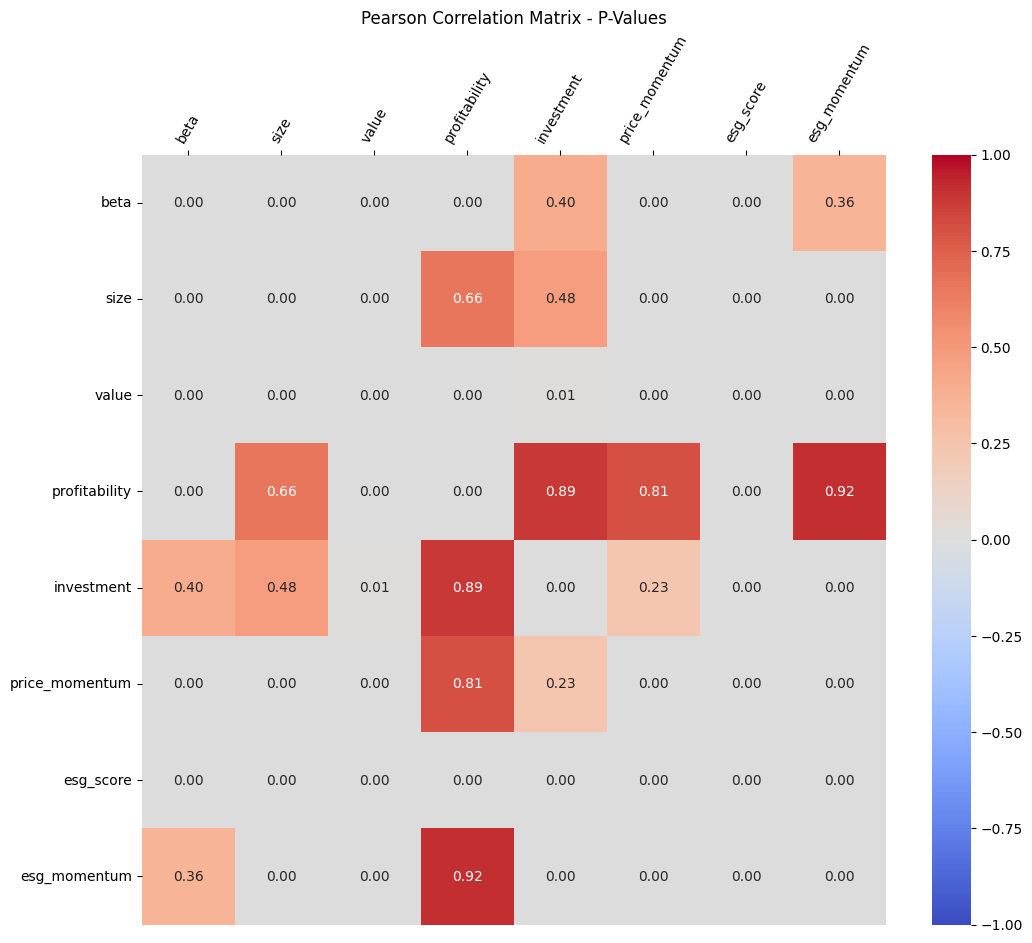

In [18]:
plotHeatmap(pval_matrix_pearson, "Pearson Correlation Matrix - P-Values")